# Detección de QR codes — YOLOv9

Pipeline:
1. Carga YOLOv9 (`michelin_v2`)
2. Inferencia filtrando solo `qr_code` (clase 1)
3. Compara predicciones con ground truth de `new_samples`
4. Métricas reales: IoU bbox, Precision, Recall
5. Guarda visualizaciones en `outputs/figures/qr_detection/`

**Colores:** verde = ground truth · amarillo = predicción

## 1. Cargar modelo

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

WEIGHTS       = "../utils/runs/data/runs/michelin_v1/weights/best.pt"
QR_CLASS      = 1
CONF_THR      = 0.40
IOU_THR       = 0.5
MAX_BOX_RATIO = 0.15

COLOR_GT   = (0, 220, 80)
COLOR_PRED = (255, 220, 0)

model = YOLO(WEIGHTS)
print(f"Modelo cargado: {WEIGHTS}")

Modelo cargado: ../utils/runs/data/runs/michelin_v1/weights/best.pt


## 2. Helpers

In [3]:
def filter_preds(preds, img_h, img_w):
    """Filtra QRs por clase y área, ordena por confianza y retiene top-3 (igual que qr_detection.py)."""
    raw = [(b.xyxy[0], float(b.conf[0])) for b in preds.boxes if int(b.cls[0]) == QR_CLASS]
    raw = [p for p in raw
           if (int(p[0][2]) - int(p[0][0])) * (int(p[0][3]) - int(p[0][1])) / (img_h * img_w) <= MAX_BOX_RATIO]
    raw = sorted(raw, key=lambda p: p[1], reverse=True)[:3]
    boxes = [[*map(int, p[0])] for p in raw]
    confs = [p[1] for p in raw]
    return boxes, confs


def load_gt_qr(label_path, img_w, img_h):
    boxes = []
    if not Path(label_path).exists():
        return boxes
    for line in Path(label_path).read_text().splitlines():
        parts = line.strip().split()
        if not parts or int(parts[0]) != QR_CLASS:
            continue
        cx, cy, w, h = map(float, parts[1:])
        x1 = (cx - w / 2) * img_w
        y1 = (cy - h / 2) * img_h
        x2 = (cx + w / 2) * img_w
        y2 = (cy + h / 2) * img_h
        boxes.append([x1, y1, x2, y2])
    return boxes


def bbox_iou(a, b):
    ix1 = max(a[0], b[0]);  iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]);  iy2 = min(a[3], b[3])
    inter  = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def match_predictions(gt_boxes, pred_boxes, iou_thr=IOU_THR):
    matched_gt   = set()
    matched_pred = set()
    tp_ious = []
    for pi, pred in enumerate(pred_boxes):
        best_iou, best_gi = 0.0, -1
        for gi, gt in enumerate(gt_boxes):
            if gi in matched_gt:
                continue
            iou = bbox_iou(pred, gt)
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_iou >= iou_thr:
            tp_ious.append(best_iou)
            matched_gt.add(best_gi)
            matched_pred.add(pi)
    n_fp = len(pred_boxes) - len(matched_pred)
    n_fn = len(gt_boxes)   - len(matched_gt)
    return tp_ious, n_fp, n_fn


print("Helpers listos.")

Helpers listos.


## 3. Test sobre una imagen

GT QRs: 3  |  Predichos: 3
TP: 3  FP: 0  FN: 0
IoU medio (TP): 0.715


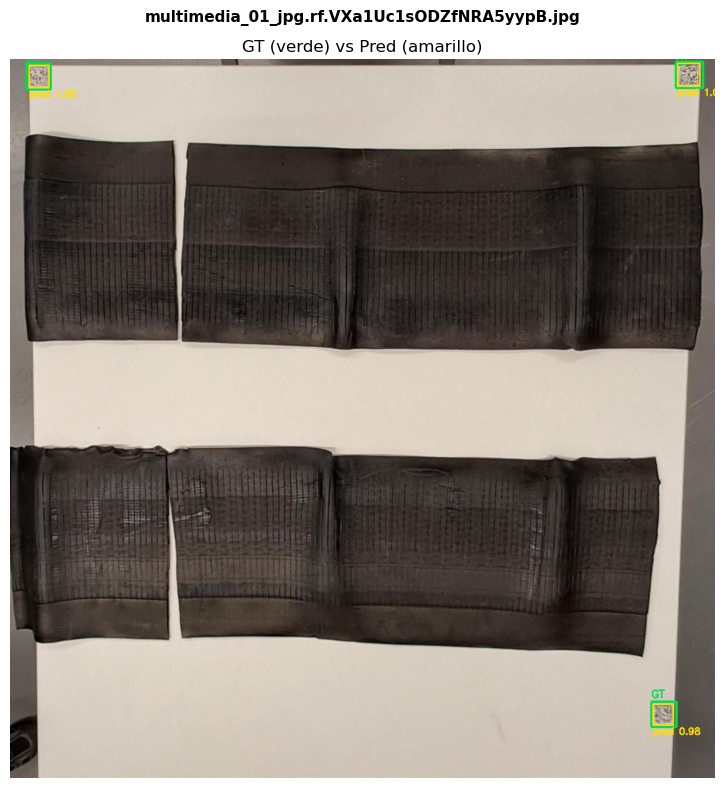

In [4]:
DATA_ROOT = Path("../data/new_samples_qr_rubber")

sample_img = sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))[0]
sample_lbl = DATA_ROOT / "train" / "labels" / (sample_img.stem + ".txt")

img_bgr = cv2.imread(str(sample_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

gt_boxes = load_gt_qr(sample_lbl, W, H)
preds    = model(img_bgr, verbose=False, conf=CONF_THR)[0]
pred_boxes, pred_confs = filter_preds(preds, H, W)

tp_ious, n_fp, n_fn = match_predictions(gt_boxes, pred_boxes)
print(f"GT QRs: {len(gt_boxes)}  |  Predichos: {len(pred_boxes)}")
print(f"TP: {len(tp_ious)}  FP: {n_fp}  FN: {n_fn}")
if tp_ious:
    print(f"IoU medio (TP): {np.mean(tp_ious):.3f}")

overlay = img_rgb.copy()
for box in gt_boxes:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_GT, 3)
    cv2.putText(overlay, "GT", (x1, max(y1-8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, COLOR_GT, 2)
for box, conf in zip(pred_boxes, pred_confs):
    x1, y1, x2, y2 = box
    cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_PRED, 2)
    cv2.putText(overlay, f"pred {conf:.2f}", (x1, y2+18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_PRED, 2)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(overlay)
ax.set_title("GT (verde) vs Pred (amarillo)")
ax.axis("off")
fig.suptitle(sample_img.name, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Evaluación sobre todo el dataset (train + valid)

In [5]:
DATA_ROOT = Path("../data/new_samples_qr_rubber")

all_imgs = [
    (img, DATA_ROOT / "train" / "labels" / (img.stem + ".txt"))
    for img in sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))
] + [
    (img, DATA_ROOT / "valid" / "labels" / (img.stem + ".txt"))
    for img in sorted((DATA_ROOT / "valid" / "images").glob("*.jpg"))
]
print(f"Total imágenes: {len(all_imgs)}")

total_tp, total_fp, total_fn = 0, 0, 0
all_tp_ious = []
per_image   = []

for img_path, lbl_path in all_imgs:
    img_bgr  = cv2.imread(str(img_path))
    H, W     = img_bgr.shape[:2]
    gt_boxes = load_gt_qr(lbl_path, W, H)
    preds    = model(img_bgr, verbose=False, conf=CONF_THR)[0]
    pred_boxes, _ = filter_preds(preds, H, W)

    tp_ious, n_fp, n_fn = match_predictions(gt_boxes, pred_boxes)
    total_tp += len(tp_ious)
    total_fp += n_fp
    total_fn += n_fn
    all_tp_ious.extend(tp_ious)

    per_image.append({
        "name":     img_path.name,
        "gt":       len(gt_boxes),
        "pred":     len(pred_boxes),
        "tp":       len(tp_ious),
        "fp":       n_fp,
        "fn":       n_fn,
        "iou_mean": np.mean(tp_ious) if tp_ious else None,
    })

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*55}")
print(f"TP: {total_tp}  FP: {total_fp}  FN: {total_fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
if all_tp_ious:
    print(f"IoU medio (TP): {np.mean(all_tp_ious):.3f}")

print(f"\n{'Imagen':<50} {'GT':>4} {'Pred':>5} {'TP':>4} {'FP':>4} {'FN':>4} {'IoU':>6}")
print("-" * 80)
for r in per_image:
    iou_str = f"{r['iou_mean']:.3f}" if r["iou_mean"] is not None else "  — "
    print(f"{r['name']:<50} {r['gt']:>4} {r['pred']:>5} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {iou_str:>6}")

Total imágenes: 22

TP: 64  FP: 0  FN: 0
Precision: 1.000
Recall:    1.000
F1:        1.000
IoU medio (TP): 0.765

Imagen                                               GT  Pred   TP   FP   FN    IoU
--------------------------------------------------------------------------------
multimedia_01_jpg.rf.VXa1Uc1sODZfNRA5yypB.jpg         3     3    3    0    0  0.715
multimedia_02_jpg.rf.Oj3RZ61LrtxiLIH6Q2qV.jpg         3     3    3    0    0  0.799
multimedia_04_jpg.rf.MGHdsSXWAqCvpoTV9eEz.jpg         3     3    3    0    0  0.760
multimedia_05_jpg.rf.UmwCstSbCbadDh62kdyj.jpg         3     3    3    0    0  0.729
multimedia_07_jpg.rf.rzxqe1IXC3fkfze6QTtc.jpg         3     3    3    0    0  0.762
multimedia_08_jpg.rf.Z7rzyNv5BaX4JsejH44T.jpg         2     2    2    0    0  0.786
multimedia_09_jpg.rf.4yp5FkHpPSDiJCr0gnE6.jpg         3     3    3    0    0  0.821
multimedia_10_jpg.rf.wxfQCr6OUG88R64iwuod.jpg         3     3    3    0    0  0.842
multimedia_11_jpg.rf.U2X6VMrXEcfhMHZ1Plqu.jpg   

## 5. Guardar visualizaciones

In [6]:
OUT_DIR = Path("outputs/figures/qr_detection")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for img_path, lbl_path in all_imgs:
    img_bgr  = cv2.imread(str(img_path))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W     = img_rgb.shape[:2]
    gt_boxes = load_gt_qr(lbl_path, W, H)
    preds    = model(img_bgr, verbose=False, conf=CONF_THR)[0]
    pred_boxes, pred_confs = filter_preds(preds, H, W)

    tp_ious, n_fp, n_fn = match_predictions(gt_boxes, pred_boxes)

    overlay = img_rgb.copy()
    for box in gt_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_GT, 3)
        cv2.putText(overlay, "GT", (x1, max(y1-8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, COLOR_GT, 2)
    for box, conf in zip(pred_boxes, pred_confs):
        x1, y1, x2, y2 = box
        cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_PRED, 2)
        cv2.putText(overlay, f"pred {conf:.2f}", (x1, y2+18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_PRED, 2)

    iou_str  = f"IoU={np.mean(tp_ious):.3f}" if tp_ious else "IoU=nulo"
    subtitle = f"GT={len(gt_boxes)}  Pred={len(pred_boxes)}  TP={len(tp_ious)}  FP={n_fp}  FN={n_fn}  {iou_str}"

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(overlay)
    ax.set_title("GT (verde) vs Pred (amarillo)")
    ax.axis("off")
    fig.suptitle(f"{img_path.name}\n{subtitle}", fontsize=10, fontweight="bold")
    plt.tight_layout()

    plt.savefig(OUT_DIR / f"{img_path.stem}.jpg", dpi=100, bbox_inches="tight")
    plt.close()
    print(f"  {img_path.name} → {subtitle}")

print(f"\nFiguras guardadas en: {OUT_DIR.resolve()}")

  multimedia_01_jpg.rf.VXa1Uc1sODZfNRA5yypB.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.715
  multimedia_02_jpg.rf.Oj3RZ61LrtxiLIH6Q2qV.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.799
  multimedia_04_jpg.rf.MGHdsSXWAqCvpoTV9eEz.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.760
  multimedia_05_jpg.rf.UmwCstSbCbadDh62kdyj.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.729
  multimedia_07_jpg.rf.rzxqe1IXC3fkfze6QTtc.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.762
  multimedia_08_jpg.rf.Z7rzyNv5BaX4JsejH44T.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.786
  multimedia_09_jpg.rf.4yp5FkHpPSDiJCr0gnE6.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.821
  multimedia_10_jpg.rf.wxfQCr6OUG88R64iwuod.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.842
  multimedia_11_jpg.rf.U2X6VMrXEcfhMHZ1Plqu.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.741
  multimedia_12_jpg.rf.WIFwzmQEF0m39hjVPpFX.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0  IoU=0.750
  multimedia_13_jpg.rf.QuEMlo9c5B0h2k2x4EHV.jpg → GT=3  Pred=3  TP=3  FP=0  FN=0

## 6. Exportar posiciones QR y homografías a JSON

Para cada imagen raw, detecta los QRs, etiqueta TL/TR/BR/BL por posición, calcula la homografía H y guarda todo en `../outputs/detections/qr_homographies.json`.
Este fichero es la entrada de `cut_edge_measurement.ipynb`.

In [7]:
import json

OUTPUT_SIZE = (1000, 1400)
OUT_W, OUT_H = OUTPUT_SIZE
RAW_DIR  = Path("../data/raw")
OUT_JSON = Path("outputs/detections/qr_homographies.json")
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)


def _label_by_position(centers_dict):
    """Asigna TL/TR/BR/BL a un dict {idx: (cx,cy)} por posición relativa."""
    pts = np.array(list(centers_dict.values()), dtype=np.float32)
    idxs = list(centers_dict.keys())
    s    = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).reshape(-1)
    labels = {}
    labels[idxs[np.argmin(s)]]    = 'TL'
    labels[idxs[np.argmax(s)]]    = 'BR'
    labels[idxs[np.argmin(diff)]] = 'TR'
    labels[idxs[np.argmax(diff)]] = 'BL'
    return labels


def _compute_H(qr_centers):
    """qr_centers: dict {'TL':(cx,cy), 'TR':..., 'BR':..., 'BL':...}"""
    req = ['TL', 'TR', 'BR', 'BL']
    available = [k for k in req if k in qr_centers]
    dst_map = {'TL':(0,0), 'TR':(OUT_W,0), 'BR':(OUT_W,OUT_H), 'BL':(0,OUT_H)}
    if len(available) == 4:
        src = np.array([qr_centers[k] for k in req], dtype=np.float32)
        dst = np.array([dst_map[k]     for k in req], dtype=np.float32)
        H, _ = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        return H
    if len(available) >= 3:
        src = np.array([qr_centers[k] for k in available[:3]], dtype=np.float32)
        dst = np.array([dst_map[k]     for k in available[:3]], dtype=np.float32)
        A = cv2.getAffineTransform(src, dst)
        return np.vstack([A, [0, 0, 1]]).astype(np.float32)
    return None


image_paths = sorted(RAW_DIR.glob("*.jpg"))
print(f"Imágenes a procesar: {len(image_paths)}")

homographies = {}

for img_path in image_paths:
    img_bgr = cv2.imread(str(img_path))
    ih, iw  = img_bgr.shape[:2]
    preds   = model(img_bgr, verbose=False, conf=CONF_THR)[0]

    boxes = [
        b for b in preds.boxes
        if int(b.cls[0]) == QR_CLASS
        and (int(b.xyxy[0][2])-int(b.xyxy[0][0])) * (int(b.xyxy[0][3])-int(b.xyxy[0][1])) / (ih * iw) <= MAX_BOX_RATIO
    ]

    if len(boxes) < 3:
        print(f"  [SKIP] {img_path.name}: solo {len(boxes)} QRs")
        continue

    centers = {i: (float((b.xyxy[0][0]+b.xyxy[0][2])/2),
                   float((b.xyxy[0][1]+b.xyxy[0][3])/2))
               for i, b in enumerate(boxes)}

    labels  = _label_by_position(centers)
    qr_pos  = {lbl: list(centers[idx]) for idx, lbl in labels.items()}

    H_mat = _compute_H(qr_pos)
    if H_mat is None:
        print(f"  [ERR] {img_path.name}: no se pudo calcular H")
        continue

    homographies[img_path.name] = {
        "qrs": qr_pos,
        "H":   H_mat.tolist(),
    }
    print(f"  {img_path.name}: QRs={list(qr_pos.keys())}")

OUT_JSON.write_text(json.dumps(homographies, indent=2))
print(f"\nGuardado en: {OUT_JSON.resolve()}")

Imágenes a procesar: 22
  multimedia_01.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_02.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_03.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_04.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_05.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_06.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_07.jpg: QRs=['TL', 'TR', 'BL']
  [SKIP] multimedia_08.jpg: solo 2 QRs
  multimedia_09.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_10.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_11.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_12.jpg: QRs=['TL', 'BL', 'TR']
  multimedia_13.jpg: QRs=['BL', 'BR', 'TR']
  [SKIP] multimedia_14.jpg: solo 2 QRs
  multimedia_15.jpg: QRs=['TL', 'TR', 'BL']
  multimedia_16.jpg: QRs=['TL', 'TR', 'BL']
  multimedia_17.jpg: QRs=['TL', 'TR', 'BL']
  multimedia_18.jpg: QRs=['TL', 'TR', 'BL']
  multimedia_19.jpg: QRs=['TL', 'TR', 'BL']
  multimedia_20.jpg: QRs=['TL', 'TR', 'BL']
  multimedia_21.jpg: QRs=['TL', 'TR', 'BL']
  multimedia_22.jpg: QRs=['TL', 'BL', 'TR']

Guardado en: C:\U